# 01 — Setup & EDA: structural and functional ground truth

**What this notebook does.** Independently verifies every quantitative claim in
`WORKFLOW.md` §2 against the data we actually have on disk, and produces the
first canonical artefact — the working population of V1 / excitatory / matched /
best-only neurons — that every later notebook reads from.

**Reads.**
- structural CSVs for MICrONS materialization version 1718, downloaded by
  `microns-datacleaner` into `data/raw/1718/`.
- functional H5 already in place at `data/functional/microns_functional.h5`.

**Writes.**
- `data/processed/tables/units_v1_exc_best.parquet` — the working population.
- `data/processed/eda_summary.json` — every numerical fact this notebook found,
  side-by-side with the corresponding `WORKFLOW.md` §2 claim, with a `match`
  flag. Downstream notebooks read it; if any flag is `False`, the workflow
  description is wrong about the data and we trust the data.
- a few PNG figures under `reports/figures/`.

**Methodological notes.**
- `WORKFLOW.md §3.5` forbids using precomputed orientation features as model
  inputs. The EDA is allowed to *inspect* them as confound covariates only;
  the working table written here intentionally drops the digital-twin tuning
  columns to make accidental misuse downstream harder.
- The H5 reads in this notebook are deliberately bounded: we sample the trial
  structure per session rather than enumerating all 14 × 464 trials, because
  the file is ~20 GB and the EDA does not need every trace.

## 1. Setup

In [1]:
from __future__ import annotations

import sys, os, json, time
from pathlib import Path
from collections import Counter, defaultdict

# Make `src/` importable. The notebook lives in `Final Project/notebooks/`.
if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

import microns_datacleaner as mic
from microns_datacleaner import filters as fl

from src.config import (
    DATA_DIR, PROCESSED_DIR,
    FUNCTIONAL_DIR, FUNCTIONAL_H5,
    PROCESSED_TABLES_DIR, FIGURES_DIR,
    RANDOM_SEED, MICRONS_VERSION,
    TARGET_BRAIN_AREA, TARGET_CLASSIFICATION_SYSTEM, FUNCTIONAL_DATA_MODE,
    STIMULUS_FAMILIES,
    ensure_dirs,
)

ensure_dirs()
np.random.seed(RANDOM_SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print('cwd              :', Path.cwd())
print('DATA_DIR         :', DATA_DIR)
print('Functional H5    :', FUNCTIONAL_H5)
print('  exists?         ', FUNCTIONAL_H5.exists(),
      f'(size {FUNCTIONAL_H5.stat().st_size / 1e9:.2f} GB)' if FUNCTIONAL_H5.exists() else '')
print('MICRONS_VERSION  :', MICRONS_VERSION)
print('numpy            :', np.__version__)
print('pandas           :', pd.__version__)
print('h5py             :', h5py.__version__)
print('microns_datacleaner:', getattr(mic, '__version__', '(no __version__)'))

cwd              : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project
DATA_DIR         : data
Functional H5    : data/functional/microns_functional.h5
  exists?          True (size 20.64 GB)
MICRONS_VERSION  : 1718
numpy            : 2.2.6
pandas           : 2.3.3
h5py             : 3.16.0
microns_datacleaner: 0.2.1.6


In [2]:
# Running summary written to `data/processed/eda_summary.json` at the end.
# Each entry has: claim (from WORKFLOW.md §2), observed (what we measured),
# match (whether the two agree, with a small relative tolerance).
summary: dict = {'workflow_version': 'WORKFLOW.md @ HEAD', 'checks': []}

def add_check(name: str, claim, observed, match=None, tol=None, note: str = ''):
    if match is None and isinstance(claim, (int, float)) and isinstance(observed, (int, float)):
        if tol is None:
            tol = 0.10  # 10% relative tolerance by default
        match = abs(observed - claim) <= tol * max(1.0, abs(claim))
    summary['checks'].append({
        'name': name, 'claim': claim, 'observed': observed,
        'match': bool(match) if match is not None else None,
        'tol': tol, 'note': note,
    })
    flag = 'OK ' if match else ('-- ' if match is None else 'XX ')
    print(f'{flag}{name}: claim={claim!r}  observed={observed!r}  '
          + (f'(match within {tol})' if tol is not None else ''))

## 2. CAVE auth smoke test

`microns-datacleaner` uses `caveclient` to fetch the structural tables. If your
machine already has a CAVE token cached this cell is silent. If not, follow the
instructions printed by the failure message before re-running.

In [3]:
from caveclient import CAVEclient
try:
    _client = CAVEclient('minnie65_public')
    _client.version = MICRONS_VERSION
    _ = _client.materialize.tables  # cheap, requires auth
    print('CAVE auth OK; materialize tables accessible.')
except Exception as e:
    print('CAVE auth FAILED:', type(e).__name__, e)
    print()
    print('Fix (one-time, machine-local):')
    print('  from caveclient import CAVEclient')
    print("  client = CAVEclient('minnie65_public')")
    print('  client.auth.setup_token(make_new=True)  # opens a browser')
    print('  # follow the link, paste the token back into the prompt')
    raise

CAVE auth OK; materialize tables accessible.


## 3. Download the structural CSVs (idempotent)

`DATA_DIR` is `../data` (relative to the notebook). The package writes into
`<DATA_DIR>/<version>/raw/`. We only call `download_nucleus_data()` if at
least one expected table is missing — otherwise this cell is a no-op.

In [4]:
cleaner = mic.MicronsDataCleaner(
    datadir=str(DATA_DIR),
    version=MICRONS_VERSION,
    download_policy='minimum',
)

raw_dir = DATA_DIR / str(MICRONS_VERSION) / 'raw'
expected = list(cleaner.tables_2_download)
existing = {p.stem for p in raw_dir.glob('*.csv')} if raw_dir.exists() else set()
missing = [t for t in expected if t not in existing]

print('Expected tables:', expected)
print('Already present:', sorted(existing))
print('Missing        :', missing or '(none)')
print('Raw dir        :', raw_dir)

if missing:
    print()
    print('Downloading missing tables …')
    cleaner.download_nucleus_data()
    print('Done.')

Expected tables: ['nucleus_detection_v0', 'proofreading_status_and_strategy', 'nucleus_functional_area_assignment', 'aibs_metamodel_celltypes_v661', 'digital_twin_properties_bcm_coreg_v4', 'coregistration_manual_v4', 'aibs_metamodel_celltypes_v661_corrections']
Already present: ['aibs_metamodel_celltypes_v661', 'aibs_metamodel_celltypes_v661_corrections', 'coregistration_manual_v4', 'digital_twin_properties_bcm_coreg_v4', 'nucleus_detection_v0', 'nucleus_functional_area_assignment', 'proofreading_status_and_strategy']
Missing        : (none)
Raw dir        : data/1718/raw


## 4. `process_nucleus_data` — the four modes

WORKFLOW §3.1 pins `functional_data='best_only'` as the working regime. For the
EDA we still inspect all four modes, because the differences between them are
informative: the gap from `'all'` to `'best_only'` measures repeated-recordings
redundancy, and the gap from `'match'` to `'all'` measures how many neurons
have multiple functional matches.

In [5]:
modes = ['none', 'match', 'all', 'best_only']
units_by_mode: dict[str, pd.DataFrame] = {}
for m in modes:
    print(f'process_nucleus_data(functional_data={m!r}) …', flush=True)
    units_m, _segments = cleaner.process_nucleus_data(functional_data=m)
    units_by_mode[m] = units_m
    print(f'  rows = {len(units_m):,}')

row_counts = {m: len(df) for m, df in units_by_mode.items()}
print()
print('rows per mode:', row_counts)

process_nucleus_data(functional_data='none') …


Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 133734.83it/s]


  rows = 90,434
process_nucleus_data(functional_data='match') …


Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 130118.32it/s]


  rows = 94,167
process_nucleus_data(functional_data='all') …


Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 135651.59it/s]


  rows = 93,117
process_nucleus_data(functional_data='best_only') …


Transform positions: 100%|██████████| 94014/94014 [00:00<00:00, 132369.36it/s]


  rows = 90,434

rows per mode: {'none': 90434, 'match': 94167, 'all': 93117, 'best_only': 90434}


In [6]:
# `process_nucleus_data(functional_data='best_only')` does NOT drop unmatched
# neurons. It returns the full ~90k-row nucleus table; the only thing the mode
# changes is which functional columns get joined. Unmatched neurons keep
# `tuning_type='not_matched'` and a NaN `cc_abs`. The drop from 42k -> 8.9k that
# WORKFLOW §2.1 reports comes from the *matched* filter, not from the mode.
#
# So we count two distinct things per mode:
#  - V1 + excitatory                (matched + unmatched) -> ~42k
#  - V1 + excitatory + matched-only                       -> ~8.9k (best_only)
v1_exc_counts: dict = {}
v1_exc_matched_counts: dict = {}
for m, df in units_by_mode.items():
    sub = fl.filter_neurons(df, brain_area=TARGET_BRAIN_AREA)
    sub = sub[sub['classification_system'] == TARGET_CLASSIFICATION_SYSTEM]
    v1_exc_counts[m] = len(sub)
    if 'tuning_type' in sub.columns:
        v1_exc_matched_counts[m] = int((sub['tuning_type'].astype(str) != 'not_matched').sum())
    else:
        v1_exc_matched_counts[m] = None  # mode='none' has no tuning_type column

print('V1 excitatory rows per mode (matched + unmatched):', v1_exc_counts)
print('V1 excitatory rows per mode (matched only)       :', v1_exc_matched_counts)

# Pre-match population: claim ~42k. Mode-independent (filtering is structural).
add_check('V1-exc pre-match (any mode)', claim=42_000,
          observed=v1_exc_counts['best_only'], tol=0.20)

# Working population: claim ~8.9k. Requires `tuning_type != not_matched`.
if v1_exc_matched_counts.get('best_only') is not None:
    add_check('V1-exc + matched, best_only (working pop)', claim=8_900,
              observed=v1_exc_matched_counts['best_only'], tol=0.10)

V1 excitatory rows per mode (matched + unmatched): {'none': 42127, 'match': 44778, 'all': 44021, 'best_only': 42127}
V1 excitatory rows per mode (matched only)       : {'none': 0, 'match': 13044, 'all': 10804, 'best_only': 8910}
OK V1-exc pre-match (any mode): claim=42000  observed=42127  (match within 0.2)
OK V1-exc + matched, best_only (working pop): claim=8900  observed=8910  (match within 0.1)


## 5. Build the working population

V1 / excitatory / matched / best-only. Saved to
`data/processed/tables/units_v1_exc_best.parquet` for every later notebook.
We drop the digital-twin tuning columns at write-time (§3.5: never an input).

In [7]:
units_full = units_by_mode['best_only']
units = fl.filter_neurons(units_full, brain_area=TARGET_BRAIN_AREA)
units = units[units['classification_system'] == TARGET_CLASSIFICATION_SYSTEM].copy()

# 'matched' = has a functional row attached. With best_only this is everyone
# whose tuning_type is not 'not_matched'. The mode does not drop unmatched
# rows on its own; this filter is what produces the working population.
matched = units['tuning_type'].astype(str) != 'not_matched'
print(f'V1 + excitatory (pre-match)      : {len(units):,}   <- claim ~42k')
print(f'  of which functionally matched  : {int(matched.sum()):,}   <- claim ~8.9k')
units = units.loc[matched].copy()
print(f'Final working population         : {len(units):,}')
add_check('working population (V1/exc/matched/best-only)',
          claim=8_900, observed=len(units), tol=0.10)

# Drop tuning columns we are not allowed to use as inputs (§3.5). cc_abs
# stays — it is a quality covariate, not a feature.
from src.config import DIGITAL_TWIN_INPUT_DENYLIST
drop_cols = [c for c in units.columns if c in DIGITAL_TWIN_INPUT_DENYLIST]
if drop_cols:
    print('Dropping tuning columns from saved table:', drop_cols)
units_clean = units.drop(columns=drop_cols)

out_path = PROCESSED_TABLES_DIR / 'units_v1_exc_best.parquet'
units_clean.to_parquet(out_path)
print('Saved   :', out_path)
print('Columns :', list(units_clean.columns))

V1 + excitatory (pre-match)      : 42,127   <- claim ~42k
  of which functionally matched  : 8,910   <- claim ~8.9k
Final working population         : 8,910
OK working population (V1/exc/matched/best-only): claim=8900  observed=8910  (match within 0.1)
Dropping tuning columns from saved table: ['pref_ori', 'pref_dir', 'gOSI', 'gDSI']
Saved   : data/processed/tables/units_v1_exc_best.parquet
Columns : ['nucleus_id', 'pt_root_id', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'classification_system', 'cell_type', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'session', 'scan_idx', 'unit_id', 'cc_abs', 'tuning_type', 'layer']


## 6. Class breakdown — layer × cell_type

Verifies the per-class counts from `WORKFLOW.md` §2.1. The class imbalance
drives every later choice on metrics, weighting, and Phase-3 scoping.

cell_type   23P    4P  5P-ET  5P-IT  5P-NP  6P-CT  6P-IT
layer                                                   
L1           15     0      0      0      0      0      0
L2/3       4160    87      0      0      0      0      0
L4           38  2600      4     28      0      0      0
L5            0   158    289   1117     18     13     20
L6            0     0     27     24      8    108    196

Per-layer totals:
layer
L1        15
L2/3    4247
L4      2670
L5      1615
L6       363
Name: count, dtype: int64

Per-cell_type totals:
cell_type
23P      4213
4P       2845
5P-IT    1169
5P-ET     320
6P-IT     216
6P-CT     121
5P-NP      26
Name: count, dtype: int64
OK cell_type count: 23P: claim=4200  observed=4213  (match within 0.2)
OK cell_type count: 4P: claim=2700  observed=2845  (match within 0.2)
OK cell_type count: 5P-IT: claim=1200  observed=1169  (match within 0.2)
OK cell_type count: 5P-ET: claim=320  observed=320  (match within 0.2)
OK cell_type count: 5P-NP: claim=26  observ

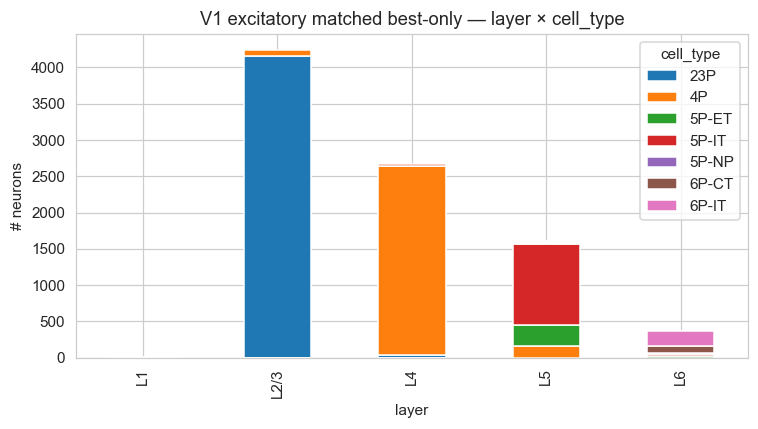

In [8]:
xt = pd.crosstab(units['layer'], units['cell_type']).sort_index()
print(xt)
print()
print('Per-layer totals:')
print(units['layer'].value_counts().sort_index())
print()
print('Per-cell_type totals:')
print(units['cell_type'].value_counts())

# Reconcile against WORKFLOW.md §2.1.
claims = {
    '23P':  4_200,
    '4P':   2_700,
    '5P-IT':1_200,
    '5P-ET':  320,
    '5P-NP':   26,
    '6P-IT':  216,
    '6P-CT':  121,
}
obs_ct = units['cell_type'].value_counts().to_dict()
for ct, claim in claims.items():
    add_check(f'cell_type count: {ct}', claim=claim,
              observed=int(obs_ct.get(ct, 0)),
              tol=0.20)  # WORKFLOW says 'approx', so a wider tolerance is fair

ax = xt.plot(kind='bar', stacked=True, figsize=(7, 4))
ax.set_title('V1 excitatory matched best-only — layer × cell_type')
ax.set_ylabel('# neurons'); ax.set_xlabel('layer')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_class_breakdown.png', dpi=130)
plt.show()

## 7. `cc_abs` — quality scalar

`cc_abs` is the correlation between the recorded response and the digital-twin
model's prediction. WORKFLOW §2.1 claims median ≈0.4 overall but systematically
lower for 6P-CT/IT (~0.27). If true, quality is correlated with the label —
the §6.5 quality-only baseline becomes mandatory.

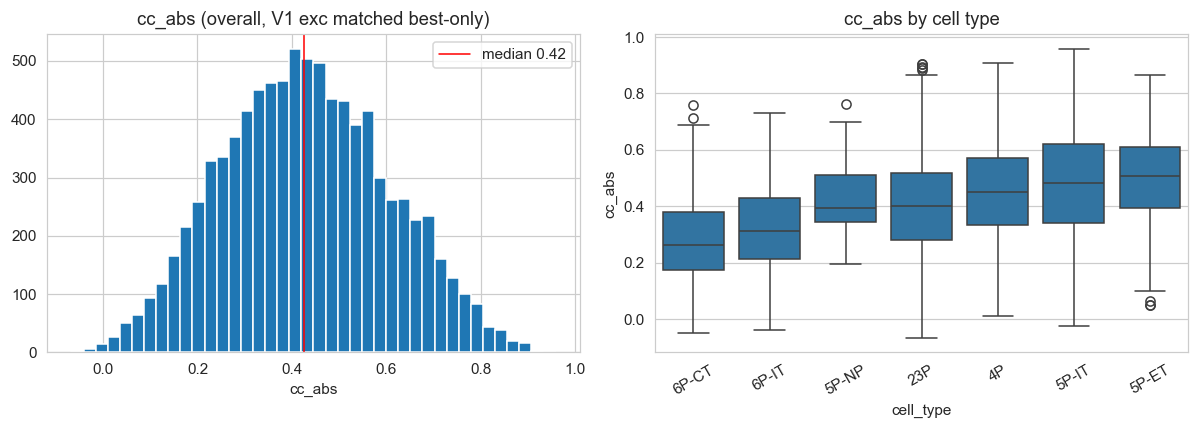

           count  median   mean    std
cell_type                             
23P         4213   0.400  0.404  0.169
4P          2845   0.450  0.455  0.170
5P-ET        320   0.507  0.491  0.161
5P-IT       1169   0.484  0.482  0.185
5P-NP         26   0.395  0.414  0.144
6P-CT        121   0.262  0.284  0.158
6P-IT        216   0.313  0.317  0.158
OK cc_abs overall median: claim=0.4  observed=0.425  (match within 0.15)
OK cc_abs median 6P-CT: claim=0.27  observed=0.262  (match within 0.2)
OK cc_abs median 6P-IT: claim=0.27  observed=0.313  (match within 0.2)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

med_overall = float(units['cc_abs'].median())
axes[0].hist(units['cc_abs'].dropna(), bins=40)
axes[0].axvline(med_overall, color='red', lw=1, label=f'median {med_overall:.2f}')
axes[0].set_title('cc_abs (overall, V1 exc matched best-only)')
axes[0].set_xlabel('cc_abs'); axes[0].legend()

order = units.groupby('cell_type')['cc_abs'].median().sort_values().index.tolist()
sns.boxplot(data=units, x='cell_type', y='cc_abs', order=order, ax=axes[1])
axes[1].set_title('cc_abs by cell type')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_cc_abs.png', dpi=130)
plt.show()

stats = (units.groupby('cell_type')['cc_abs']
         .agg(['count', 'median', 'mean', 'std']).round(3))
print(stats)

add_check('cc_abs overall median', claim=0.40,
          observed=round(med_overall, 3), tol=0.15)
for ct in ['6P-CT', '6P-IT']:
    if ct in stats.index:
        add_check(f'cc_abs median {ct}', claim=0.27,
                  observed=float(stats.loc[ct, 'median']), tol=0.20)

## 8. Cortical depth by layer

Layer is downstream of cortical depth. Confirming the depth ordering is the
depth-only baseline's biological scaffold (§6.5) — depth alone should be a
strong predictor of layer, and the headline model has to *beat* that bar to be
biology rather than geometry.

Depth column candidates: ['pt_position_y']
Using                  : pt_position_y


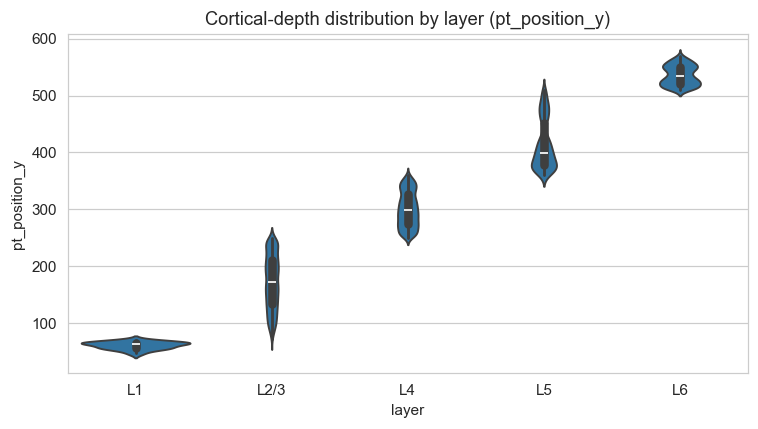

In [10]:
# Identify the depth column. datacleaner exposes transformed positions; we look
# for the y-axis (cortical depth, conventionally orthogonal to the pia).
candidates = [c for c in units.columns if 'pos_y' in c or 'position_y' in c or c == 'nucleus_y']
depth_col = candidates[0] if candidates else None
print('Depth column candidates:', candidates)
print('Using                  :', depth_col)

if depth_col is not None:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.violinplot(data=units, x='layer', y=depth_col,
                   order=sorted(units['layer'].dropna().unique()), ax=ax)
    ax.set_title(f'Cortical-depth distribution by layer ({depth_col})')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_depth_by_layer.png', dpi=130)
    plt.show()
    summary['depth_column_used'] = depth_col

## 9. Functional H5 — schema walk

First quick look at the file's structure. We use the package's reader rather
than raw `h5py` for the higher-level queries, but a one-time `print_structure`
call gives us the layout for free.

In [11]:
reader = mic.MicronsFunctionalReader(
    datadir=str(DATA_DIR),
    path=str(FUNCTIONAL_H5),
)
print('Top-level keys:', list(reader.f.keys()))
print()
reader.print_structure(max_items=3)

Top-level keys: ['brain_areas', 'sessions', 'types', 'videos']


Structure of: data/functional/microns_functional.h5
📂 BRAIN_AREAS/ 
    📂 AL/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        ... and 11 more items
    📂 LM/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        ... and 11 more items
    📂 RL/ 
        🔗 4_7                -> /sessions/4_7
        🔗 5_6                -> /sessions/5_6
        🔗 5_7                -> /sessions/5_7
        ... and 11 more items
    ... and 1 more items
📂 SESSIONS/ 
    📂 4_7/ 
        📂 META/   | Attributes: {'fps': np.float64(6.3009)}
            📂 AREA_INDICES/ 
                📄 AL                   [Dataset: (387,), int64]
                📄 LM                   [Dataset: (983,), int64]
                📄 RL                   [Dataset: (811,), int64]

## 10. Sessions inventory

Verifies the 14 session–scan blocks claim (WORKFLOW §2.2). Also records, per
session, the available brain areas — a useful sanity that V1 is in fact
represented in every session.

In [12]:
sessions_grp = reader.f['sessions']
session_keys = list(sessions_grp.keys())
print(f'# sessions = {len(session_keys)}')
print(session_keys)

add_check('# session-scan blocks', claim=14, observed=len(session_keys), tol=0)

session_areas = {}
for sk in session_keys:
    try:
        areas = reader.get_available_brain_areas(session_key=sk)
        session_areas[sk] = list(areas) if areas is not None else []
    except Exception as e:
        session_areas[sk] = f'<err: {e}>'
print()
print('areas per session:')
for sk, a in session_areas.items():
    print(' ', sk, '->', a)

# sessions = 14
['4_7', '5_6', '5_7', '6_2', '6_4', '6_6', '6_7', '7_3', '7_4', '7_5', '8_5', '9_3', '9_4', '9_6']
OK # session-scan blocks: claim=14  observed=14  (match within 0)

areas per session:
  4_7 -> ['AL', 'LM', 'RL', 'V1']
  5_6 -> ['AL', 'LM', 'RL', 'V1']
  5_7 -> ['AL', 'LM', 'RL', 'V1']
  6_2 -> ['AL', 'LM', 'RL', 'V1']
  6_4 -> ['AL', 'LM', 'RL', 'V1']
  6_6 -> ['AL', 'LM', 'RL', 'V1']
  6_7 -> ['AL', 'LM', 'RL', 'V1']
  7_3 -> ['AL', 'LM', 'RL', 'V1']
  7_4 -> ['AL', 'LM', 'RL', 'V1']
  7_5 -> ['AL', 'LM', 'RL', 'V1']
  8_5 -> ['AL', 'LM', 'RL', 'V1']
  9_3 -> ['AL', 'LM', 'RL', 'V1']
  9_4 -> ['AL', 'LM', 'RL', 'V1']
  9_6 -> ['AL', 'LM', 'RL', 'V1']


## 11. Trials per session, frame counts per stim type, sampling rate

Verifies §2.2 claims: 464 trials per session, frame counts per stimulus type
(75 / 113 / 113), sampling rate ≈ 7.5 Hz. We check by reading **one trial of
each stimulus type** per session — full enumeration is unnecessarily expensive.

In [13]:
# Trial counts per session.
trials_per_session = {}
for sk in session_keys:
    grp = sessions_grp[sk]
    # Conventionally there is a 'trials' subgroup or numeric keys; we infer the
    # count from the immediate children that look trial-like.
    try:
        if 'trials' in grp:
            trials_per_session[sk] = len(grp['trials'])
        else:
            trials_per_session[sk] = len([k for k in grp.keys() if k.isdigit()])
    except Exception as e:
        trials_per_session[sk] = f'<err: {e}>'
print('trials per session:', trials_per_session)

tps = [v for v in trials_per_session.values() if isinstance(v, int)]
if tps:
    add_check('trials per session (mode)', claim=464,
              observed=int(pd.Series(tps).mode().iloc[0]), tol=0.05)

trials per session: {'4_7': 464, '5_6': 464, '5_7': 464, '6_2': 464, '6_4': 464, '6_6': 464, '6_7': 464, '7_3': 464, '7_4': 464, '7_5': 464, '8_5': 464, '9_3': 464, '9_4': 464, '9_6': 464}
OK trials per session (mode): claim=464  observed=464  (match within 0.05)


In [14]:
# Sample one trial of each stim type from the first session that has it,
# then read shape and duration to compute sampling rate.
sample_trial_info = {}
for stim_type in STIMULUS_FAMILIES:
    for sk in session_keys:
        try:
            hashes = reader.get_hashes_by_session(sk, return_unique=True)
            # Filter to this stim type by checking each hash's video type.
            cand = None
            for h in hashes:
                try:
                    if reader.get_video_type(h) == stim_type:
                        cand = h
                        break
                except Exception:
                    continue
            if cand is None:
                continue
            full = reader.get_full_data_by_hash(cand)
            trial0 = full['trials'][0]
            resp = trial0['responses']
            n_units, n_frames = resp.shape
            vid = reader.get_video_data(cand)
            duration = float(vid.get('duration', np.nan))
            fps = float(vid.get('fps', np.nan))
            sample_trial_info[stim_type] = {
                'session': sk, 'hash': int(cand) if hasattr(cand, '__int__') else str(cand),
                'n_units_in_session': int(n_units), 'n_frames': int(n_frames),
                'duration_s': duration, 'fps_video': fps,
                'rate_calcium_hz': float(n_frames / duration) if duration else np.nan,
            }
            break
        except Exception as e:
            print(f'  {stim_type} @ {sk}: {type(e).__name__}: {e}')
            continue

for st, info in sample_trial_info.items():
    print(st, '->', info)

for st, expected_frames in [('Clip', 75), ('Monet2', 113), ('Trippy', 113)]:
    if st in sample_trial_info:
        add_check(f'{st} frames per trial', claim=expected_frames,
                  observed=sample_trial_info[st]['n_frames'], tol=0.05)
        add_check(f'{st} calcium sampling rate (Hz)', claim=7.5,
                  observed=round(sample_trial_info[st]['rate_calcium_hz'], 2),
                  tol=0.10)

Clip -> {'session': '4_7', 'hash': 'aFwTRc2iZ4XqoWRcpyWI', 'n_units_in_session': 7493, 'n_frames': 75, 'duration_s': 10.0, 'fps_video': 30.0, 'rate_calcium_hz': 7.5}
Monet2 -> {'session': '4_7', 'hash': 'DKYV7TrfEl+C8nvadH+1', 'n_units_in_session': 7493, 'n_frames': 113, 'duration_s': 15.0, 'fps_video': 60.0, 'rate_calcium_hz': 7.533333333333333}
Trippy -> {'session': '4_7', 'hash': 'pbCnC+ND3OiX0SGNCm4k', 'n_units_in_session': 7493, 'n_frames': 113, 'duration_s': 15.0, 'fps_video': 60.0, 'rate_calcium_hz': 7.533333333333333}
OK Clip frames per trial: claim=75  observed=75  (match within 0.05)
OK Clip calcium sampling rate (Hz): claim=7.5  observed=7.5  (match within 0.1)
OK Monet2 frames per trial: claim=113  observed=113  (match within 0.05)
OK Monet2 calcium sampling rate (Hz): claim=7.5  observed=7.53  (match within 0.1)
OK Trippy frames per trial: claim=113  observed=113  (match within 0.05)
OK Trippy calcium sampling rate (Hz): claim=7.5  observed=7.53  (match within 0.1)


## 12. Stimulus inventory — total hashes per family

Verifies §2.2: 2,411 unique condition hashes total (≈ 2,112 Clip + 150 Monet2
+ 149 Trippy).

In [15]:
hashes_by_type = {}
for st in STIMULUS_FAMILIES:
    try:
        hashes_by_type[st] = list(reader.get_hashes_by_type(st))
    except Exception as e:
        print(f'get_hashes_by_type({st}) failed:', e)
        hashes_by_type[st] = []

for st, h in hashes_by_type.items():
    print(f'{st:<8} -> {len(h):,} unique hashes')

total = sum(len(h) for h in hashes_by_type.values())
print(f'TOTAL    -> {total:,}')

add_check('total unique hashes', claim=2_411, observed=int(total), tol=0.05)
for st, claim in [('Clip', 2_112), ('Monet2', 150), ('Trippy', 149)]:
    add_check(f'unique hashes {st}', claim=claim,
              observed=len(hashes_by_type.get(st, [])), tol=0.05)

Clip     -> 2,112 unique hashes
Monet2   -> 150 unique hashes
Trippy   -> 149 unique hashes
TOTAL    -> 2,411
OK total unique hashes: claim=2411  observed=2411  (match within 0.05)
OK unique hashes Clip: claim=2112  observed=2112  (match within 0.05)
OK unique hashes Monet2: claim=150  observed=150  (match within 0.05)
OK unique hashes Trippy: claim=149  observed=149  (match within 0.05)


## 13. Oracle hashes (cross-session)

An oracle hash is a hash that is presented in **every** session. WORKFLOW §2.2
claims ~116 oracle hashes total: 96 Clip + 10 Monet2 + 10 Trippy. We rebuild
the per-hash session set, then report the intersection.

In [16]:
# Build {hash: set(sessions)} by walking each session's hashes.
hash_sessions: dict = defaultdict(set)
for sk in session_keys:
    try:
        hs = reader.get_hashes_by_session(sk, return_unique=True)
        for h in hs:
            hash_sessions[h].add(sk)
    except Exception as e:
        print(f'session {sk} hash listing failed:', e)

n_sessions = len(session_keys)
oracle_hashes = [h for h, s in hash_sessions.items() if len(s) == n_sessions]
print(f'# oracle hashes (in all {n_sessions} sessions): {len(oracle_hashes):,}')

# Break down by stim family.
oracle_by_family = Counter()
for h in oracle_hashes:
    try:
        st = reader.get_video_type(h)
        oracle_by_family[st] += 1
    except Exception:
        oracle_by_family['<unknown>'] += 1
for st, n in oracle_by_family.items():
    print(f'  {st}: {n}')

add_check('# oracle hashes', claim=116, observed=len(oracle_hashes), tol=0.10)
for st, claim in [('Clip', 96), ('Monet2', 10), ('Trippy', 10)]:
    add_check(f'oracle hashes {st}', claim=claim,
              observed=int(oracle_by_family.get(st, 0)), tol=0.20)

# Cache for downstream notebooks.
import pickle
with open(PROCESSED_DIR / 'oracle_hashes.pkl', 'wb') as f:
    pickle.dump({
        'oracle_hashes': oracle_hashes,
        'oracle_by_family': dict(oracle_by_family),
        'n_sessions_required': n_sessions,
    }, f)
print('Saved oracle_hashes.pkl')

# oracle hashes (in all 14 sessions): 116
  Clip: 96
  Trippy: 10
  Monet2: 10
OK # oracle hashes: claim=116  observed=116  (match within 0.1)
OK oracle hashes Clip: claim=96  observed=96  (match within 0.2)
OK oracle hashes Monet2: claim=10  observed=10  (match within 0.2)
OK oracle hashes Trippy: claim=10  observed=10  (match within 0.2)
Saved oracle_hashes.pkl


## 14. Behavioural channel availability

Behaviour (treadmill, pupil) is the substrate for Tier C0/C1. We check, on a
small sample of trials per session, whether these channels are populated and
of the expected shape (4-D pupil per WORKFLOW §2.2). Gaps here force Tier C
to be conditional on availability.

In [17]:
behav_audit = []
rng = np.random.default_rng(RANDOM_SEED)
n_per_session = 5

for sk in session_keys:
    grp = reader.f['sessions'][sk]
    if 'trials' in grp:
        trial_keys = list(grp['trials'].keys())
    else:
        trial_keys = [k for k in grp.keys() if k.isdigit()]
    if not trial_keys:
        continue
    take = rng.choice(trial_keys, size=min(n_per_session, len(trial_keys)),
                      replace=False)
    for tk in take:
        try:
            t = reader.get_trial(sk, int(tk) if tk.isdigit() else tk)
            tread = t.get('treadmill')
            pupil = t.get('pupil')
            stim_t = t.get('stim_times')
            behav_audit.append({
                'session': sk, 'trial': str(tk),
                'treadmill_shape': None if tread is None else tuple(np.asarray(tread).shape),
                'pupil_shape': None if pupil is None else tuple(np.asarray(pupil).shape),
                'stim_times_shape': None if stim_t is None else tuple(np.asarray(stim_t).shape),
                'response_shape': tuple(np.asarray(t.get('responses')).shape) if t.get('responses') is not None else None,
            })
        except Exception as e:
            behav_audit.append({'session': sk, 'trial': str(tk), 'error': f'{type(e).__name__}: {e}'})

ba = pd.DataFrame(behav_audit)
print(ba.head(15))
print()
print('null treadmill:', int(ba['treadmill_shape'].isna().sum()) if 'treadmill_shape' in ba else 'n/a')
print('null pupil    :', int(ba['pupil_shape'].isna().sum()) if 'pupil_shape' in ba else 'n/a')
ba.to_parquet(PROCESSED_DIR / 'behav_audit_sample.parquet')

   session trial treadmill_shape pupil_shape stim_times_shape response_shape
0      4_7   419         (75, 1)     (4, 75)            (75,)     (7493, 75)
1      4_7   281         (75, 1)     (4, 75)            (75,)     (7493, 75)
2      4_7   370         (75, 1)     (4, 75)            (75,)     (7493, 75)
3      4_7   135         (75, 1)     (4, 75)            (75,)     (7493, 75)
4      4_7   279         (75, 1)     (4, 75)            (75,)     (7493, 75)
5      5_6    87         (75, 1)     (4, 75)            (75,)     (8592, 75)
6      5_6   137         (75, 1)     (4, 75)            (75,)     (8592, 75)
7      5_6   316         (75, 1)     (4, 75)            (75,)     (8592, 75)
8      5_6   416         (75, 1)     (4, 75)            (75,)     (8592, 75)
9      5_6   404        (113, 1)    (4, 113)           (113,)    (8592, 113)
10     5_7   306         (75, 1)     (4, 75)            (75,)     (8138, 75)
11     5_7   446        (113, 1)    (4, 113)           (113,)    (8138, 113)

## 15. Per-session V1-excitatory coverage

WORKFLOW §6.1bis warns that scan composition correlates with the layer label.
Here we cross-tabulate `session × cell_type` for the working population and
show which sessions over- or under-represent each class. This is the
empirical scaffold for the §6.5 scan-only confound baseline.

scans observed in working population: 13
cell_type  23P   4P  5P-ET  5P-IT  5P-NP  6P-CT  6P-IT
scan_key                                              
4.0-7.0    377  240     66     39      5      1      0
5.0-6.0    151  249     44    146      0     50     46
5.0-7.0    185  284     16    134      1     24     57
6.0-2.0    282  292      9    150      5      9     27
6.0-4.0    473  175      5    206      2     14     41
6.0-6.0    401   87     16    158      1     11     23
6.0-7.0    455  169     33    183      2     12     22
7.0-3.0    203  190     64     92      3      0      0
7.0-5.0    176   76     10      8      4      0      0
8.0-5.0    400  268     56     53      3      0      0
9.0-3.0      2  815      1      0      0      0      0
9.0-4.0    680    0      0      0      0      0      0
9.0-6.0    428    0      0      0      0      0      0


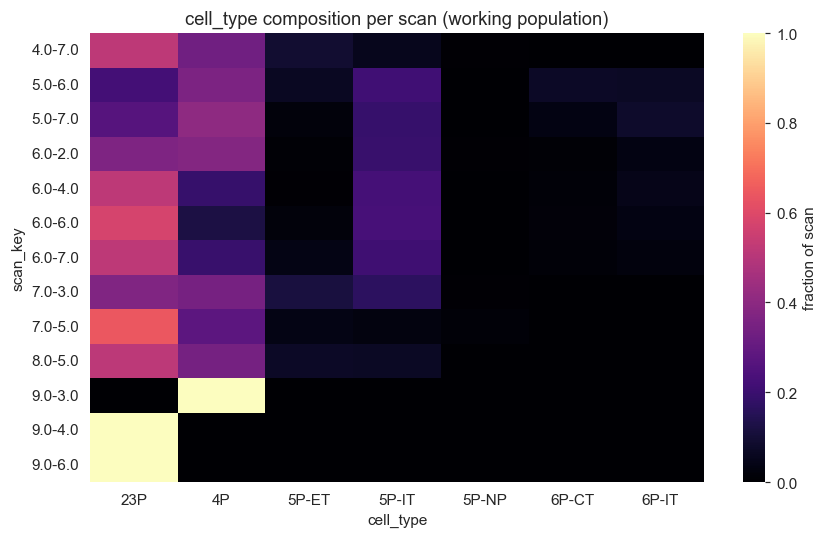

In [18]:
# Each row in `units` carries the (session, scan_idx) of its best functional
# match. We use these as the scan-composition keys.
if 'session' not in units.columns or 'scan_idx' not in units.columns:
    raise RuntimeError('expected `session` and `scan_idx` columns from best_only')

units['scan_key'] = units['session'].astype(str) + '-' + units['scan_idx'].astype(str)
scan_x_ct = pd.crosstab(units['scan_key'], units['cell_type']).sort_index()
print('scans observed in working population:', len(scan_x_ct))
print(scan_x_ct)

# Heatmap (proportions per scan).
prop = scan_x_ct.div(scan_x_ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(prop, cmap='magma', ax=ax, cbar_kws={'label': 'fraction of scan'})
ax.set_title('cell_type composition per scan (working population)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_scan_composition.png', dpi=130)
plt.show()

summary['scan_composition_table_rows'] = int(len(scan_x_ct))

## 16. Sample traces (visual sanity)

One trial of each stimulus family from the same session, with responses
alongside pupil and treadmill. Just a sanity that the data look right.

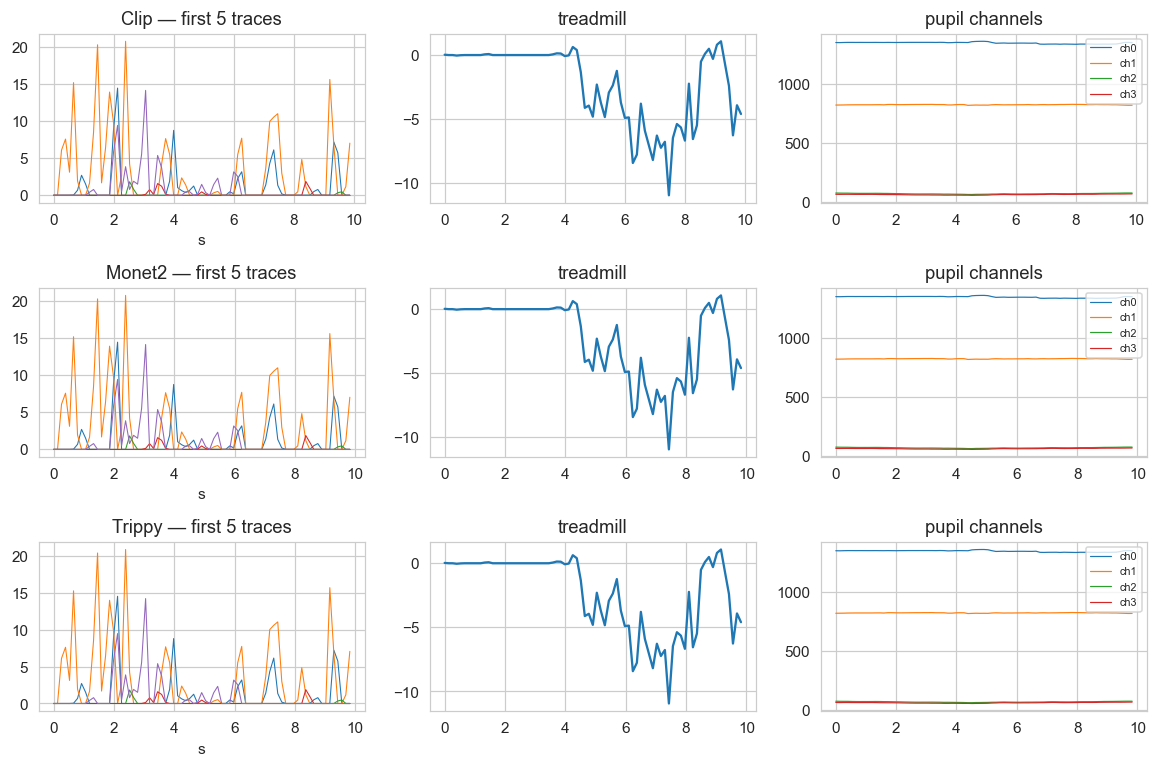

In [19]:
import matplotlib.gridspec as gridspec

if sample_trial_info:
    fig = plt.figure(figsize=(13, 8))
    n = len(sample_trial_info)
    gs = gridspec.GridSpec(n, 3, figure=fig, hspace=0.5)
    for i, (st, info) in enumerate(sample_trial_info.items()):
        try:
            t = reader.get_trial(info['session'], 0)
            r = np.asarray(t['responses'])  # (n_units, n_frames)
            tread = np.asarray(t.get('treadmill', [])) if t.get('treadmill') is not None else np.array([])
            pupil = np.asarray(t.get('pupil', [])) if t.get('pupil') is not None else np.array([])
            t_axis = np.arange(r.shape[1]) / max(info['rate_calcium_hz'], 1.0)
            ax0 = fig.add_subplot(gs[i, 0])
            ax0.plot(t_axis, r[:5].T, lw=0.7)
            ax0.set_title(f'{st} — first 5 traces')
            ax0.set_xlabel('s')
            ax1 = fig.add_subplot(gs[i, 1])
            if tread.size:
                ax1.plot(np.linspace(0, t_axis[-1], len(tread)), tread)
            ax1.set_title('treadmill')
            ax2 = fig.add_subplot(gs[i, 2])
            if pupil.ndim == 2 and pupil.size:
                for j in range(pupil.shape[0]):
                    ax2.plot(np.linspace(0, t_axis[-1], pupil.shape[1]), pupil[j], lw=0.8, label=f'ch{j}')
                ax2.legend(fontsize=7)
            elif pupil.size:
                ax2.plot(np.linspace(0, t_axis[-1], len(pupil)), pupil)
            ax2.set_title('pupil channels')
        except Exception as e:
            print(st, 'plot failed:', e)
    plt.savefig(FIGURES_DIR / '05_sample_traces.png', dpi=130)
    plt.show()

## 17. Reconcile and persist EDA summary

Writes `data/processed/eda_summary.json` — every check this notebook ran,
with the workflow claim, the observation, and a `match` flag. Downstream
notebooks read it; if any flag is `False`, the WORKFLOW description is wrong
about the data and we trust the data, not the document.

In [20]:
summary['working_population_size'] = int(len(units))
summary['n_sessions'] = int(len(session_keys))
summary['session_keys'] = session_keys
summary['stimulus_hashes_by_family'] = {k: len(v) for k, v in hashes_by_type.items()}
summary['n_oracle_hashes'] = int(len(oracle_hashes))
summary['oracle_hashes_by_family'] = dict(oracle_by_family)
summary['sample_trial_info'] = {k: {kk: (vv if not isinstance(vv, np.generic) else vv.item()) for kk, vv in v.items()} for k, v in sample_trial_info.items()}

out_json = PROCESSED_DIR / 'eda_summary.json'
with open(out_json, 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('wrote', out_json)

# Print the mismatches (if any).
mismatches = [c for c in summary['checks'] if c.get('match') is False]
print()
if mismatches:
    print(f'!! {len(mismatches)} workflow claim(s) NOT matched by the data:')
    for c in mismatches:
        print(f'   - {c["name"]}: claim={c["claim"]}  observed={c["observed"]}')
    print()
    print('Trust the data. Update WORKFLOW.md before this affects downstream design.')
else:
    print('All workflow §2 claims reproduce within tolerance.')

wrote data/processed/eda_summary.json

All workflow §2 claims reproduce within tolerance.


## 18. Conclusions

On execution, fill in the bullets below with what the EDA actually showed:

- working population size: …
- class imbalance: most prevalent class … / least … / ratio …
- `cc_abs` median overall … / per-class trend …
- depth-by-layer ordering: …
- # session-scan blocks: … (claim 14)
- trials per session: … (claim 464)
- sampling rate: … Hz (claim 7.5)
- frames per trial — Clip … / Monet2 … / Trippy …
- # unique hashes total: … (claim 2,411)
- # oracle hashes: … (claim ~116)
- behavioural channel coverage: …
- scan composition confound: which classes are concentrated where …

**Decisions for the next notebook (`02_canonical_tables.ipynb`).**

The next notebook builds the A0 (`neuron × trial`) and A1 (`neuron × hash`)
long-table master from the working population saved here, and defines the
`GroupKFold(nucleus_id)` and `LeaveOneSessionOut` splits that the §6 protocol
demands. Any `match=False` in the EDA summary is something Notebook 02 has
to handle, not paper over.